<a href="https://colab.research.google.com/github/tcdev2021/Ecommerce_Sales_Dashboard/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

In [3]:
# Display first few rows
boston_df.head()


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [4]:
# Get summary of dataset
boston_df.describe()


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [5]:
# Check column names
boston_df.columns


Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')

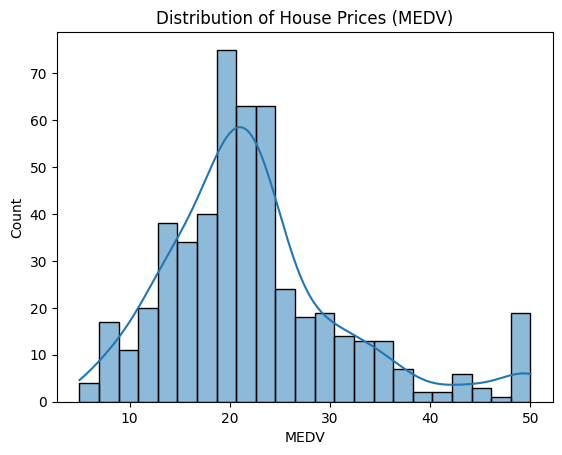

In [6]:
sns.histplot(boston_df['MEDV'], kde=True)
pyplot.title('Distribution of House Prices (MEDV)')
pyplot.show()


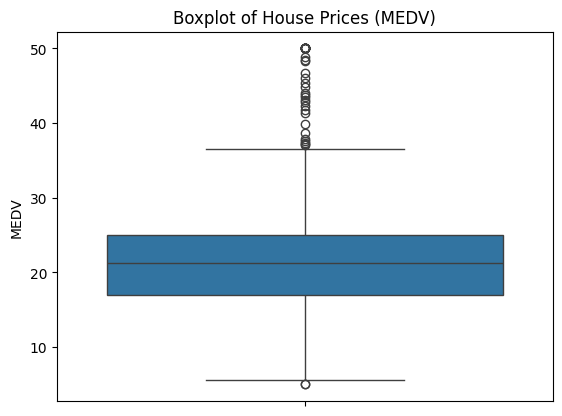

In [7]:
sns.boxplot(y=boston_df['MEDV'])
pyplot.title('Boxplot of House Prices (MEDV)')
pyplot.show()


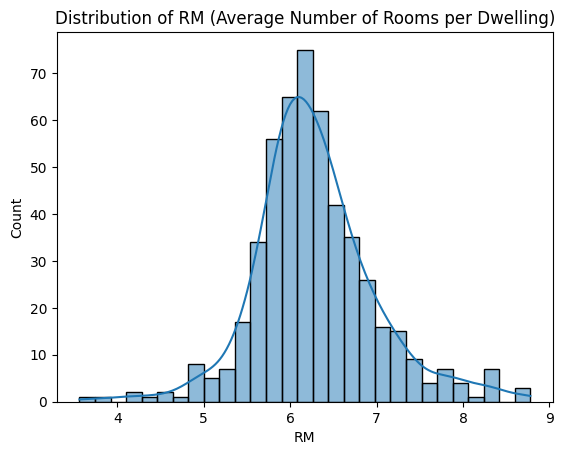

In [8]:
sns.histplot(boston_df['RM'], kde=True)
pyplot.title('Distribution of RM (Average Number of Rooms per Dwelling)')
pyplot.xlabel('RM')
pyplot.show()


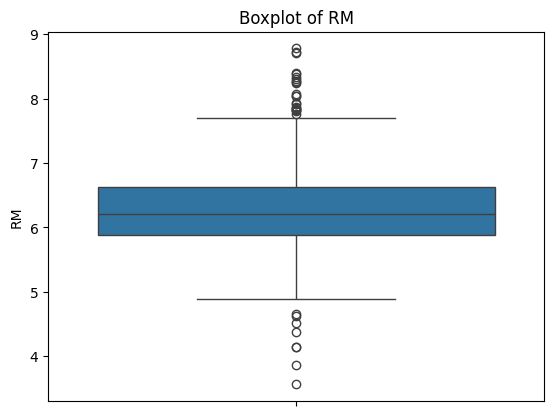

In [9]:
sns.boxplot(y=boston_df['RM'])
pyplot.title('Boxplot of RM')
pyplot.show()


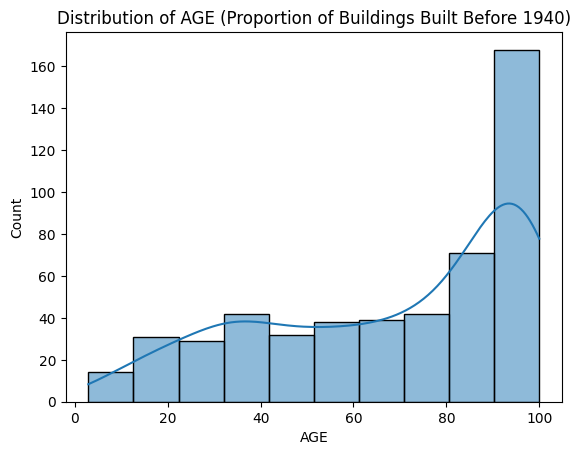

In [10]:
sns.histplot(boston_df['AGE'], kde=True)
pyplot.title('Distribution of AGE (Proportion of Buildings Built Before 1940)')
pyplot.xlabel('AGE')
pyplot.show()


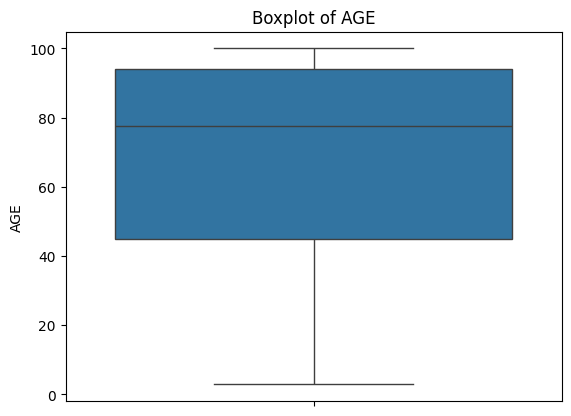

In [11]:
sns.boxplot(y=boston_df['AGE'])
pyplot.title('Boxplot of AGE')
pyplot.show()


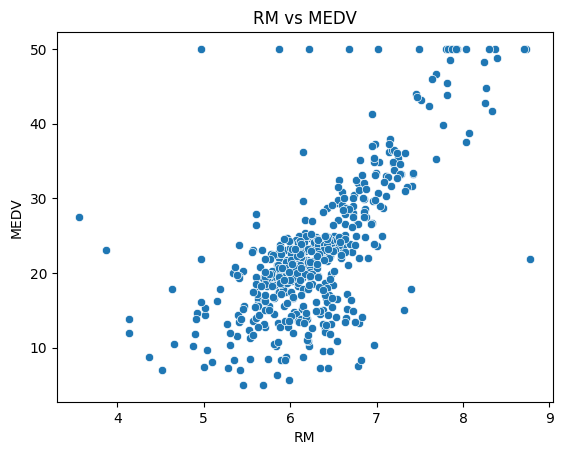

In [12]:
sns.scatterplot(x='RM', y='MEDV', data=boston_df)
pyplot.title('RM vs MEDV')
pyplot.show()


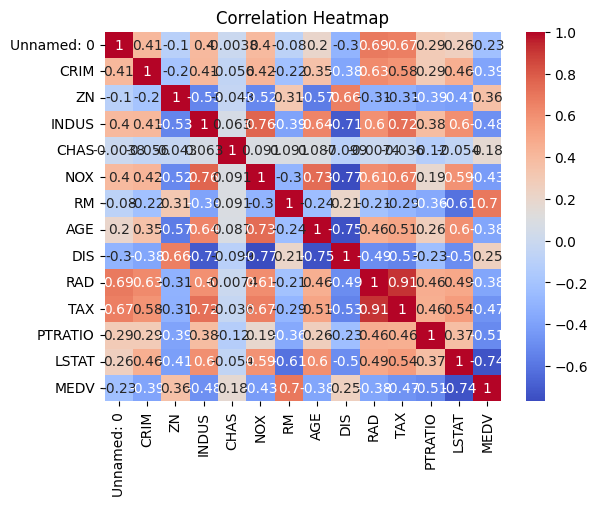

In [13]:
sns.heatmap(boston_df.corr(), annot=True, cmap='coolwarm')
pyplot.title('Correlation Heatmap')
pyplot.show()


In [14]:
river = boston_df[boston_df['CHAS']==1]['MEDV']
no_river = boston_df[boston_df['CHAS']==0]['MEDV']

scipy.stats.ttest_ind(river, no_river, equal_var=False)


TtestResult(statistic=np.float64(3.113291312794837), pvalue=np.float64(0.0035671700981375174), df=np.float64(36.876408797611994))

Since the p-value (0.0036) is less than 0.05, there is a statistically significant difference in the mean house prices between areas that are near the river and those that are not.

In [15]:
model = ols('MEDV ~ C(RAD)', data=boston_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


,sum_sq,df,F,PR(>F)
C(RAD),9767.259802,8.0,18.416048,3.125649e-24
Residual,32949.035613,497.0,NaN,NaN
